# Computer Vision Using Deep Learning - Practical 6 (i)

## 1. Import Libraries

In [27]:
import numpy as np
import pandas as pd 
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

## 2. Define Neural Network Class

In [ ]:
class NN(torch.nn.Module):
    def __init__(self, in_feat):
        super().__init__()
        self.l1 = torch.nn.Linear(in_feat, 20)   # fully-connected layer: in_feat -> 20
        self.a1 = torch.nn.ReLU()                # ReLU activation
        self.l2 = torch.nn.Linear(20, 7)         # FC: 20 -> 7  
        self.a2 = torch.nn.ReLU()                # ReLU
        self.l3 = torch.nn.Linear(7, 5)          # FC: 7 -> 5
        self.a3 = torch.nn.ReLU()                # ReLU
        self.l4 = torch.nn.Linear(5, 1)          # final linear to 1 logit
        self.a4 = torch.nn.Sigmoid()             # sigmoid to get probability [0,1]

    def forward(self, X):
        ao1 = self.a1(self.l1(X))
        ao2 = self.a2(self.l2(ao1))
        ao3 = self.a3(self.l3(ao2))
        ao4 = self.a4(self.l4(ao3))
        return ao4


## 3. Load Dataset

In [29]:

def load_dataset():
    train = h5py.File("train_catvsnoncat.h5", "r")
    test = h5py.File("test_catvsnoncat.h5", "r")

    train_x = torch.from_numpy(np.array(train['train_set_x'])).float()
    train_y = torch.from_numpy(np.array(train['train_set_y'])).float().reshape(1, -1)

    test_x = torch.from_numpy(np.array(test['test_set_x'])).float()
    test_y = torch.from_numpy(np.array(test['test_set_y'])).float().reshape(1, -1)

    original_x = np.array(train['train_set_x'])
    return train_x, train_y, test_x, test_y, original_x

X, Y, test_x, test_y, o_x = load_dataset()
print("Train X:", X.shape)
print("Train Y:", Y.shape)
print("Test X:", test_x.shape)
print("Test Y:", test_y.shape)


Train X: torch.Size([209, 64, 64, 3])
Train Y: torch.Size([1, 209])
Test X: torch.Size([50, 64, 64, 3])
Test Y: torch.Size([1, 50])


## 4. Preprocess Dataset

In [30]:
m = X.shape[0]
print("Number of training examples:", m)

train_x = X.reshape(X.shape[0], -1)
train_x = train_x / 255.0

nx = train_x.shape[1]
print("Number of features:", nx)

Number of training examples: 209
Number of features: 12288


## 5. Build Model & Optimizer

In [31]:
model = NN(nx)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0075)

## 6. Train Model

In [ ]:

for i in range(3000):
    optimizer.zero_grad()
    yhat = model(train_x)
    cost = F.binary_cross_entropy(yhat, Y.T)
    cost.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Iteration {i}, Cost: {cost.item()}")


Iteration 0, Cost: 0.6705156564712524
Iteration 100, Cost: 0.20916521549224854
Iteration 200, Cost: 0.019041700288653374
Iteration 300, Cost: 0.009221106767654419
Iteration 400, Cost: 0.00576396519318223
Iteration 500, Cost: 0.003804516512900591
Iteration 600, Cost: 0.002631582086905837
Iteration 700, Cost: 0.00188955117482692
Iteration 800, Cost: 0.0014068178134039044
Iteration 900, Cost: 0.0010780025040730834
Iteration 1000, Cost: 0.0008477402734570205
Iteration 1100, Cost: 0.0006803860305808485
Iteration 1200, Cost: 0.0005555674433708191
Iteration 1300, Cost: 0.0004608666058629751
Iteration 1400, Cost: 0.0003869759675581008
Iteration 1500, Cost: 0.0003287956933490932
Iteration 1600, Cost: 0.00028204702539369464
Iteration 1700, Cost: 0.00024382640549447387
Iteration 1800, Cost: 0.00021231493155937642
Iteration 1900, Cost: 0.00018622903735376894
Iteration 2000, Cost: 0.00016418879386037588
Iteration 2100, Cost: 0.00014558104157913476
Iteration 2200, Cost: 0.00012964336201548576
Iterat

## 7. Define Helper Functions

In [33]:

def show_dataset(x, y, rows=6, cols=6):
    fig, axs = plt.subplots(rows, cols, figsize=(7, 7))
    for i, ax in enumerate(axs.flat):
        ax.imshow(x[i])
        ax.text(0.5, -0.1, f"is cat: {y[0][i]}", va='bottom')
        ax.axis("off")

def classify(preds):
    preds[preds > 0.5] = 1
    preds[preds <= 0.5] = 0
    return preds


## 8. Predictions & Visualization

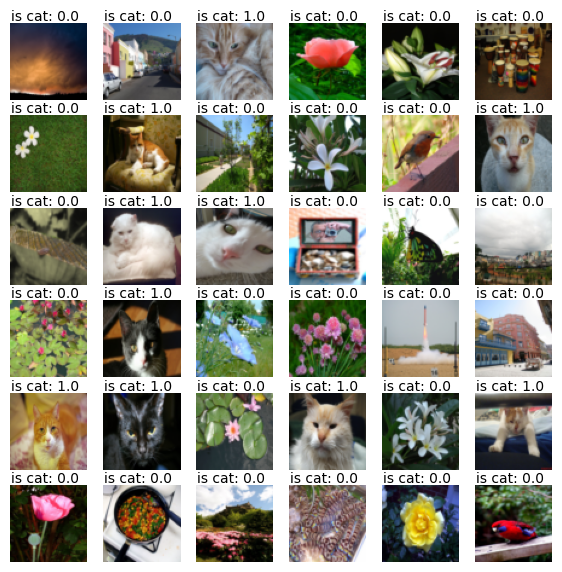

In [34]:

preds = model(train_x)
preds = classify(preds)
show_dataset(o_x, preds.T)